 STEP 1: UPLOAD YOUR 2 CSV FILES
Click 'Choose Files' and select BOTH the 100-row and 50-row files.


Saving UCS_InputsOutputs_E.csv to UCS_InputsOutputs_E.csv
Saving UCS_InputsOutputs_E_Testing.csv to UCS_InputsOutputs_E_Testing.csv

Training File loaded: UCS_InputsOutputs_E.csv
Testing File loaded: UCS_InputsOutputs_E_Testing.csv

 STEP 2: DATA CLEANING & SCALING (MULTI-TARGET)

[SUCCESS] Data is cleaned, scaled, and ready for model training!
 MODEL 1: GAUSSIAN PROCESS (KRIGING) 
Training Dual-Surface Kriging Model... (Takes ~1 min)
 -> PeakUCS Testing NSE       : 0.9906 (99.06%)
 -> YoungsModulus Testing NSE : 0.9876 (98.76%)


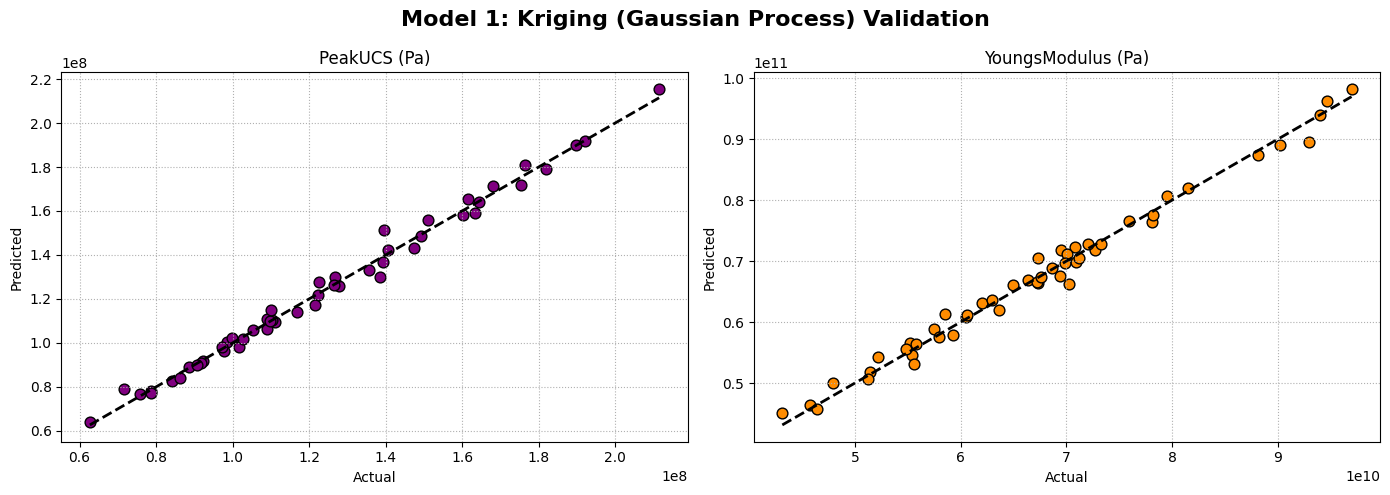

 MODEL 2: SUPPORT VECTOR REGRESSOR (SVR) 
Training SVR...
 -> PeakUCS Testing NSE       : 0.8995 (89.95%)
 -> YoungsModulus Testing NSE : 0.8828 (88.28%)


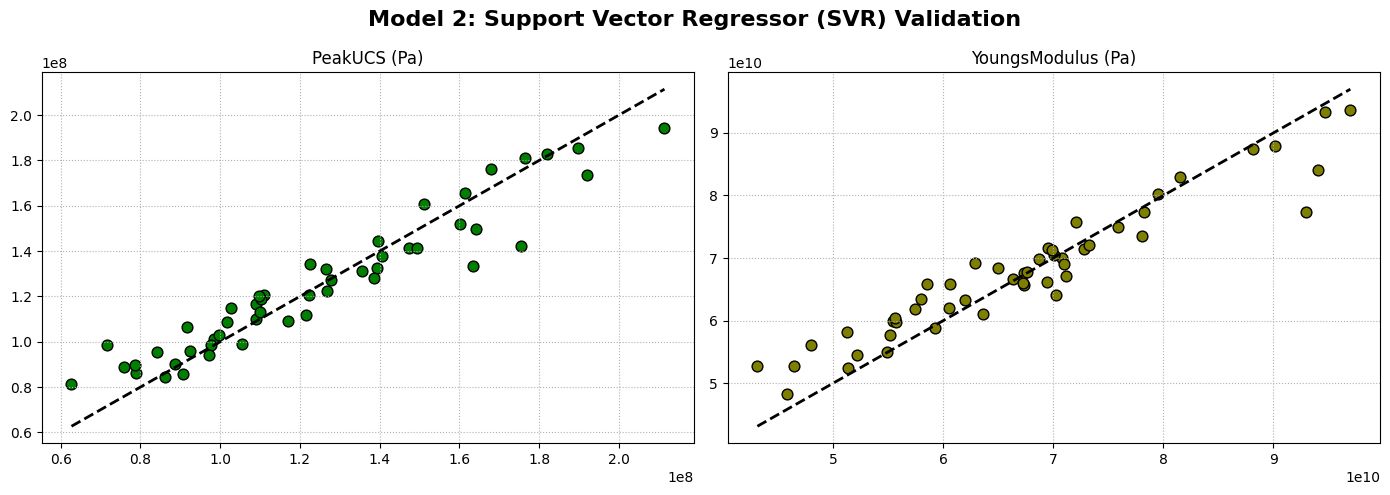

 MODEL 3: RANDOM FOREST ENSEMBLE 
Training Random Forest...
 -> PeakUCS Testing NSE       : 0.6700 (67.00%)
 -> YoungsModulus Testing NSE : 0.6043 (60.43%)


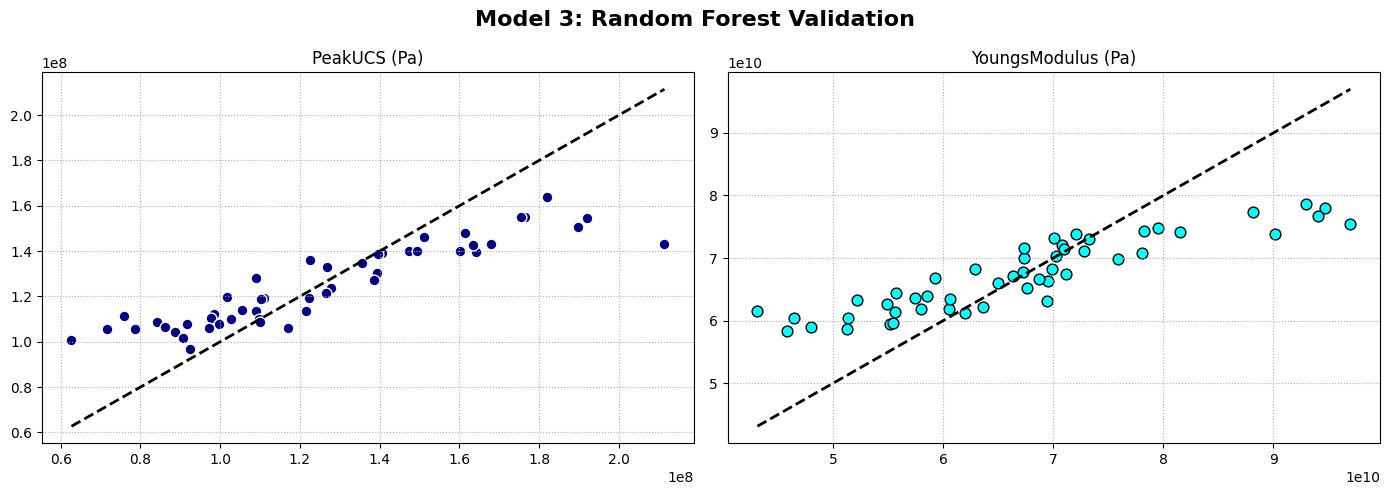

 MODEL 4: GRADIENT BOOSTING REGRESSOR 
Training Gradient Boosting Ensemble...
 -> PeakUCS Testing NSE       : 0.9751 (97.51%)
 -> YoungsModulus Testing NSE : 0.9357 (93.57%)


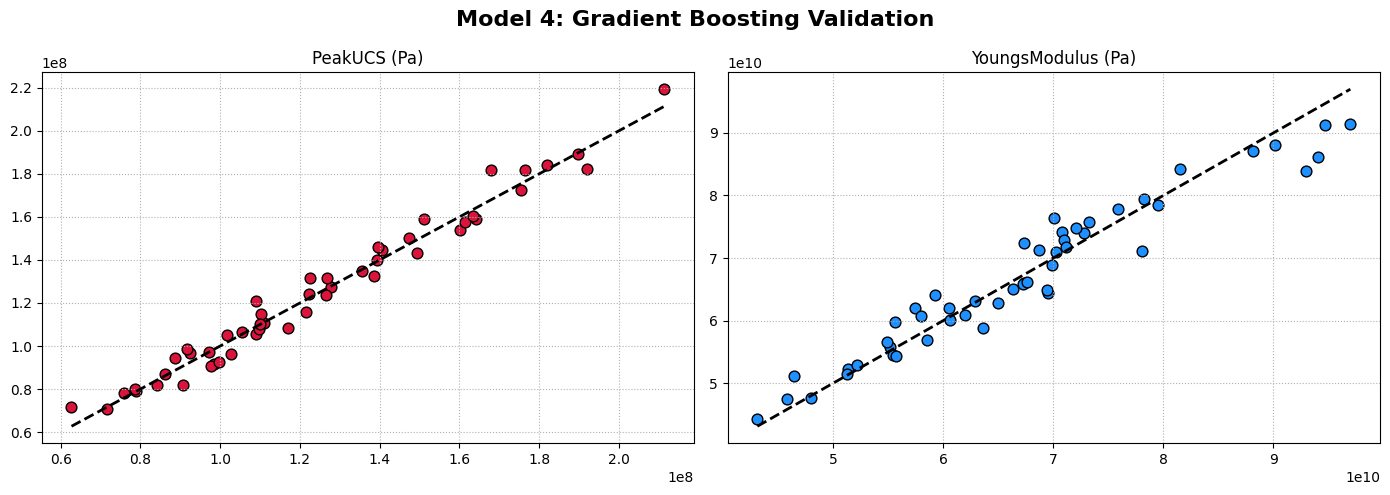

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.1/780.1 kB 3.8 MB/s eta 0:00:00
        SOBOL GLOBAL SENSITIVITY ANALYSIS
Generated Samples : 32768


Peak UCS Sobol Ranking
                   Parameter        S1        ST   S1_conf   ST_conf
11      CohesionPeak_contact  0.949630  0.949355  0.077150  0.066043
12      FrictionPeak_contact  0.040227  0.041660  0.016376  0.003839
6           CohesionResidual  0.001229  0.001683  0.003187  0.000165
13       TensionPeak_contact  0.001427  0.001316  0.003581  0.000124
0                       Bulk  0.000395  0.000647  0.002173  0.000066
3               CohesionPeak  0.000653  0.000619  0.002081  0.000068
10                Ks_contact  0.000849  0.000608  0.002282  0.000076
9                 Kn_contact  0.000205  0.000581  0.002207  0.000092
14  FrictionResidual_contact  0.001046  0.000517  0.001801  0.000076
1                      Shear  0.000222  0.000494  0.001815  0.000060
5                TensionPeak  0.000361  0.000287  0.001323  0.000031

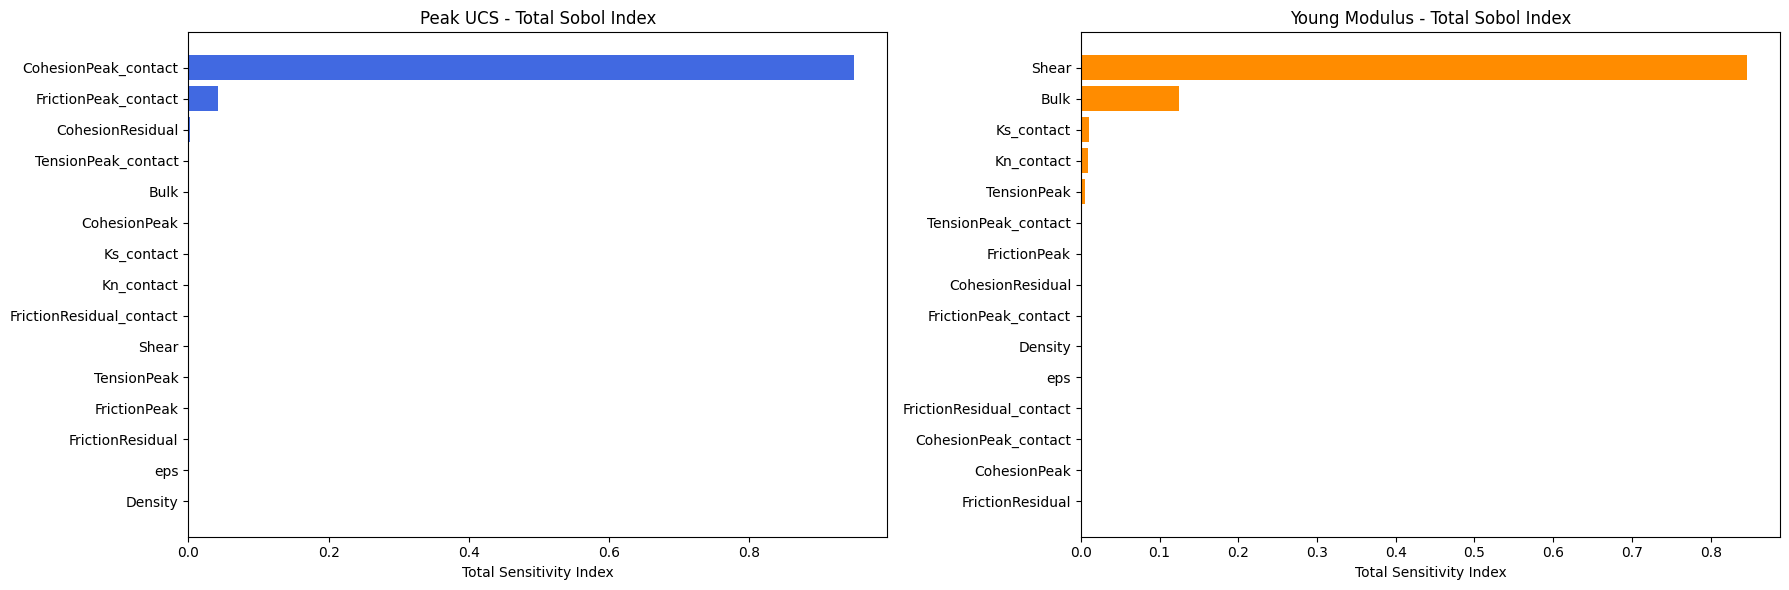

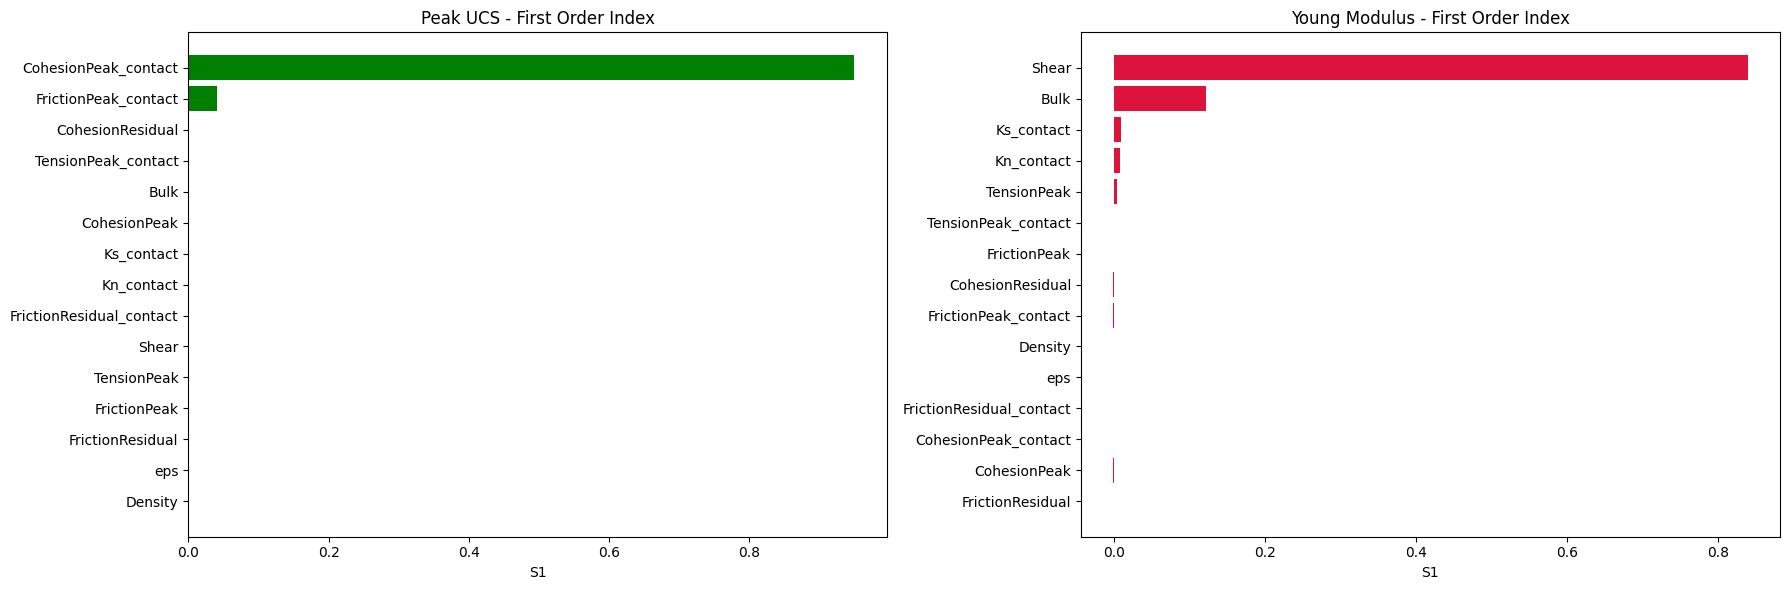

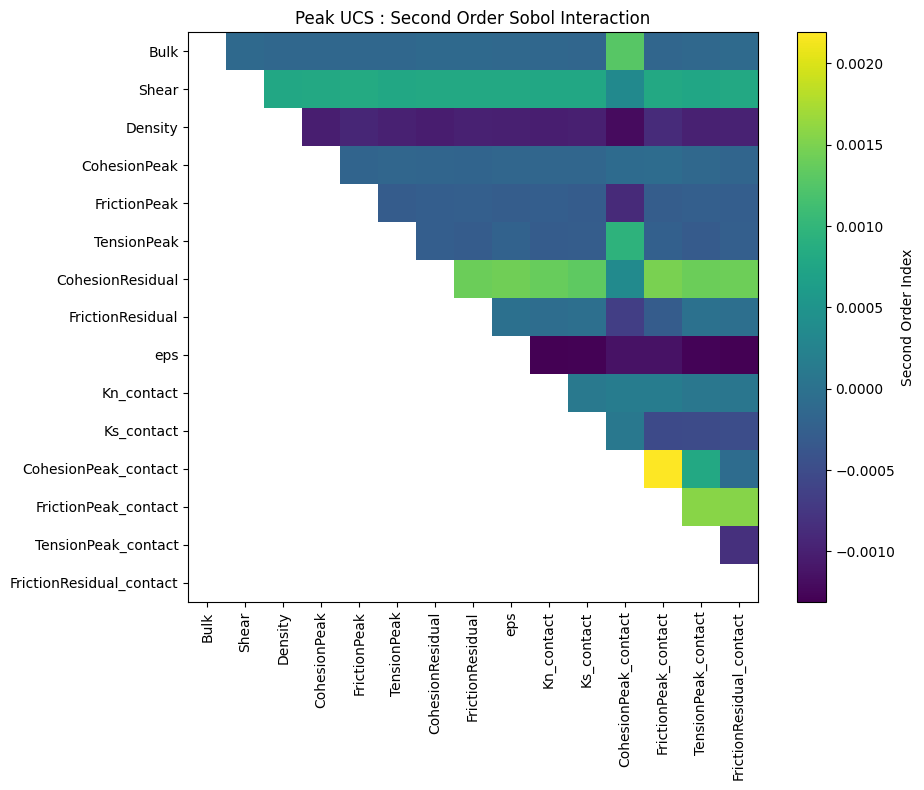

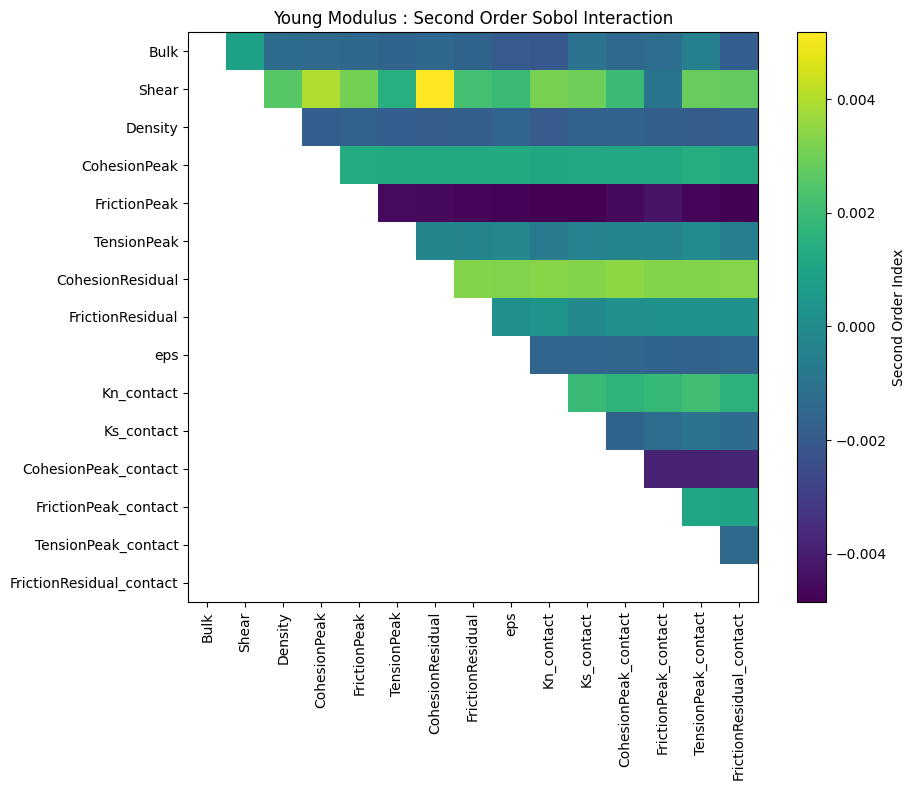


Sobol Analysis Completed Successfully.
        BORGONOVO (DELTA) SENSITIVITY ANALYSIS
Generated Samples : (5000, 15)


Peak UCS Borgonovo Ranking
                   Parameter     Delta  Delta_conf
11      CohesionPeak_contact  0.716343    0.004529
12      FrictionPeak_contact  0.077083    0.009988
2                    Density  0.064573    0.007715
3               CohesionPeak  0.063122    0.007427
5                TensionPeak  0.063084    0.007334
10                Ks_contact  0.062895    0.007565
1                      Shear  0.055004    0.007154
0                       Bulk  0.053931    0.006361
14  FrictionResidual_contact  0.053410    0.006724
9                 Kn_contact  0.051149    0.008163
8                        eps  0.050593    0.007476
13       TensionPeak_contact  0.048989    0.007428
7           FrictionResidual  0.048983    0.007570
4               FrictionPeak  0.048600    0.007307
6           CohesionResidual  0.047319    0.007443


Young Modulus Borgonovo Ranking
   

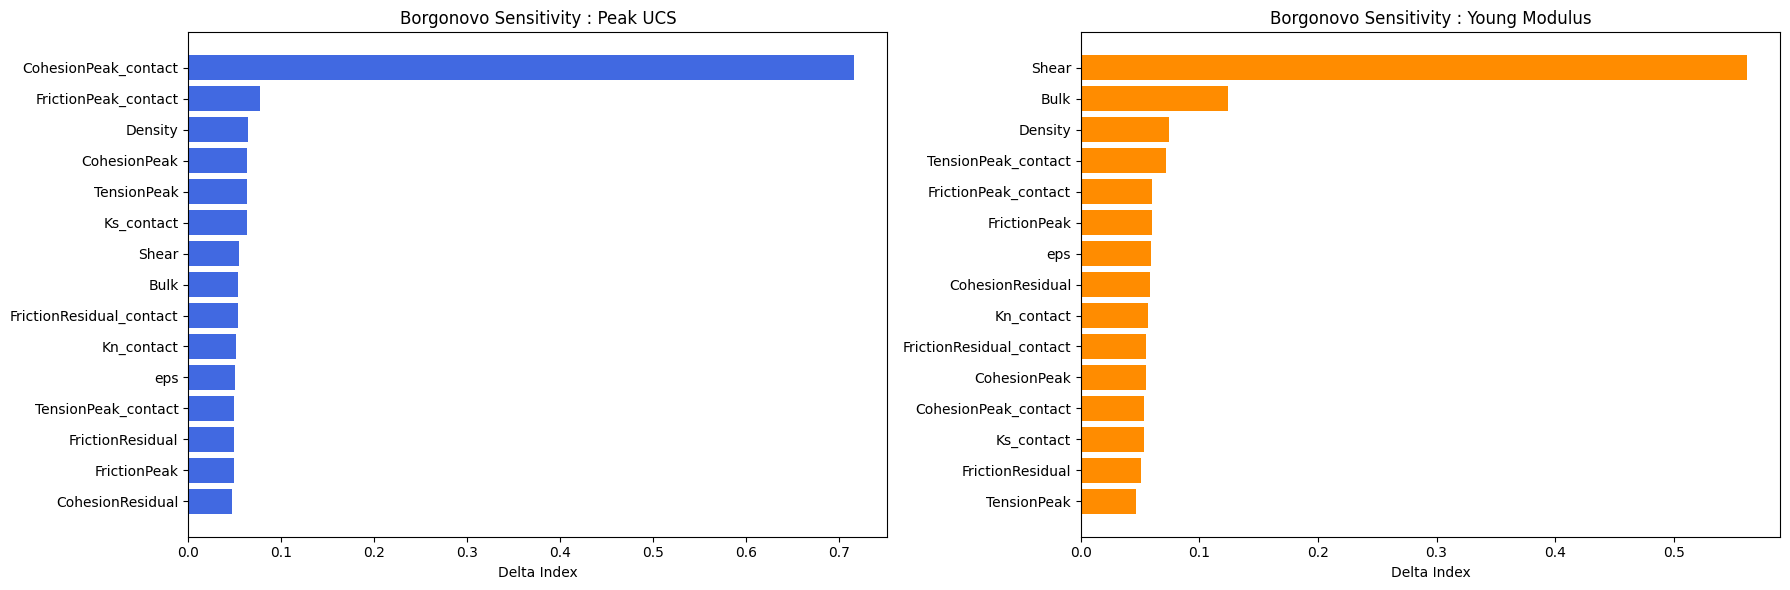


Borgonovo Analysis Completed Successfully.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 645.1 kB/s eta 0:00:00
MCMC engine initialized successfully.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

print("=========================================================")
print(" STEP 1: LOAD LOCAL CSV FILES")
print("=========================================================")

# Directly read from the 'data' folder
train_filename = "data/UCS_InputsOutputs_E.csv"
test_filename = "data/UCS_InputsOutputs_E_Testing.csv"

print(f"Training File loaded: {train_filename}")
print(f"Testing File loaded: {test_filename}")

# Load datasets
df_train = pd.read_csv(train_filename)
df_test = pd.read_csv(test_filename)

# Strip whitespace from column headers
df_train.columns = df_train.columns.str.strip()
df_test.columns = df_test.columns.str.strip()

# Separate Features (15 variables) and MULTI-TARGET (PeakUCS, YoungsModulus)
target_cols = ['PeakUCS', 'YoungsModulus']
X_train = df_train.drop(columns=target_cols)
y_train = df_train[target_cols]
X_test = df_test.drop(columns=target_cols)
y_test = df_test[target_cols]

print("\n=========================================================")
print(" STEP 2: DATA CLEANING & SCALING (MULTI-TARGET)")
print("=========================================================")

# Force convert to numeric
X_train = X_train.apply(pd.to_numeric, errors='coerce')
X_test = X_test.apply(pd.to_numeric, errors='coerce')
y_train = y_train.apply(pd.to_numeric, errors='coerce')
y_test = y_test.apply(pd.to_numeric, errors='coerce')

# Impute missing values
imputer_X = SimpleImputer(strategy='mean')
X_train_clean = imputer_X.fit_transform(X_train)
X_test_clean = imputer_X.transform(X_test)

imputer_y = SimpleImputer(strategy='mean')
y_train_clean = imputer_y.fit_transform(y_train)
y_test_clean = imputer_y.transform(y_test)

# Scale the features
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train_clean)
X_test_scaled = scaler_X.transform(X_test_clean)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train_clean)

print("\n[SUCCESS] Data is loaded directly from 'data' folder and ready!")


 STEP 1: DEFINE TARGET PROPERTIES & PARAMETER BOUNDS 
Target Mean Peak UCS : 90000000.0 Pa
Target Std Deviation : 9000000.0 Pa
 STEP 2: DEFINE BAYESIAN MCMC FUNCTIONS 
 STEP 3: RUN MCMC (METROPOLIS-HASTINGS) 
Starting MCMC Sampling with 32 walkers over 1000 steps...


100%|██████████| 1000/1000 [00:12<00:00, 77.84it/s]


MCMC Sampling Complete!
 STEP 4: PREDICT AND PLOT MICROPARAMETER PDFs 
Total usable samples extracted to form PDFs: 25600


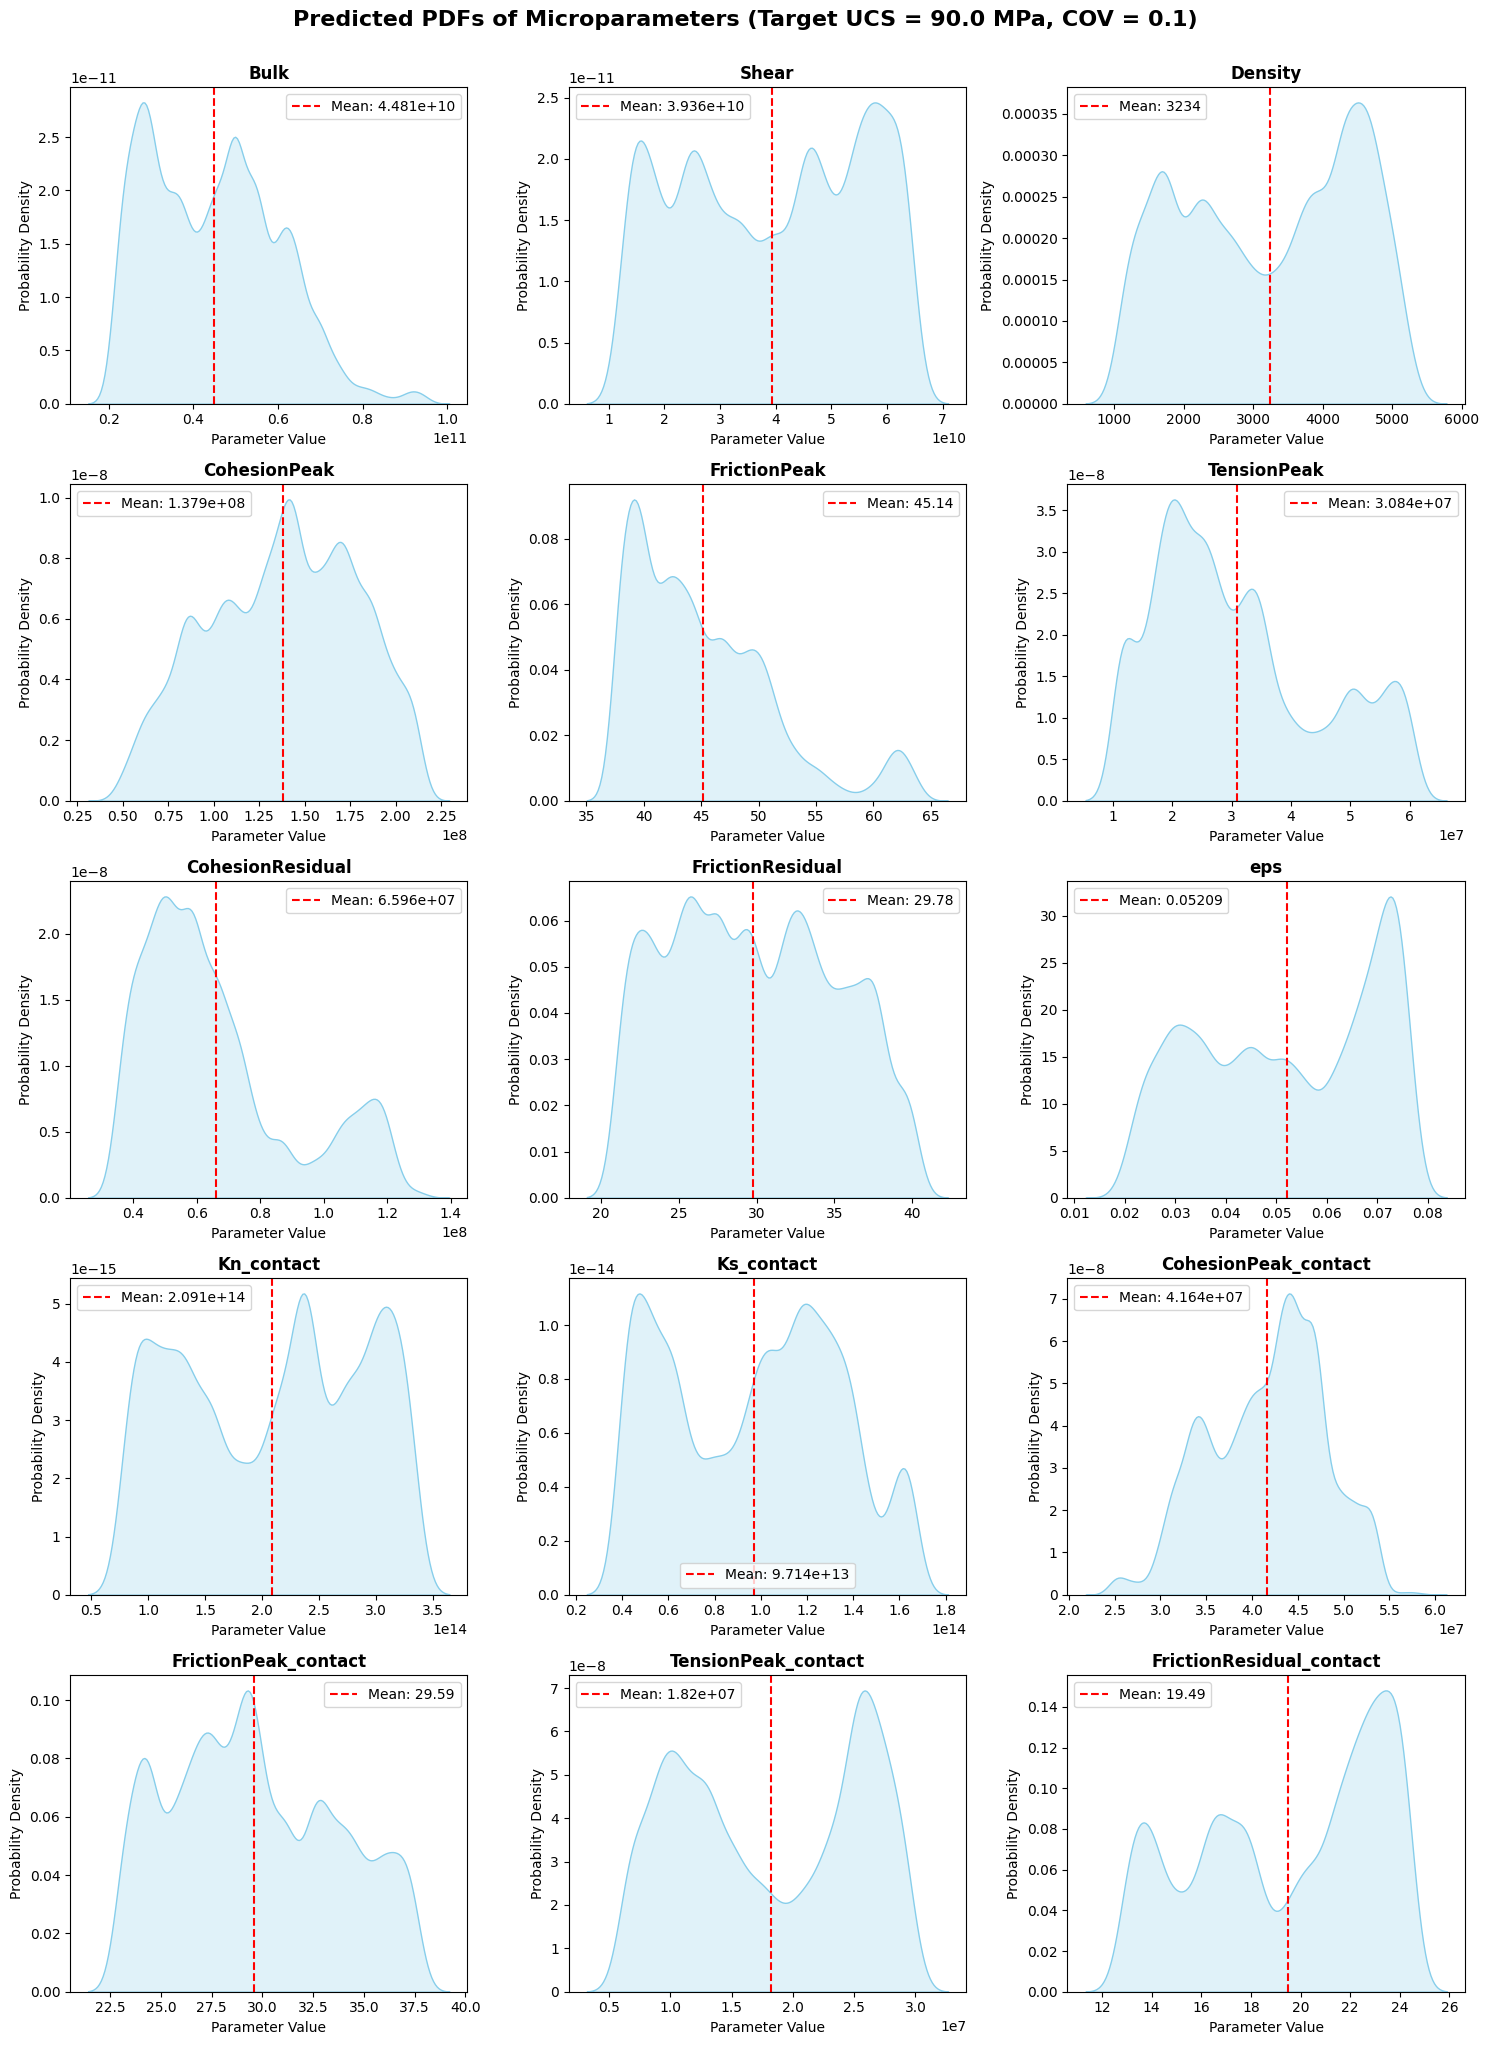

In [4]:
# Install emcee for MCMC and seaborn for beautiful PDF graphs if you don't have them yet
!pip install emcee seaborn

import emcee
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("=========================================================")
print(" STEP 1: DEFINE TARGET PROPERTIES & PARAMETER BOUNDS ")
print("=========================================================")

# 1. Target Definition:
# Set your target mean value for the Peak UCS (e.g., 50 MPa).
target_ucs_mean = 90e6  # Adjust this value based on your specific requirements

# Set the Coefficient of Variation (COV). e.g., 0.10 means a 10% allowed variance.
cov = 0.10
target_ucs_std = target_ucs_mean * cov  # Standard Deviation = Mean * COV

print(f"Target Mean Peak UCS : {target_ucs_mean} Pa")
print(f"Target Std Deviation : {target_ucs_std} Pa")

# 2. Set Min/Max Ranges for Microparameters:
# FIX: Hum yahan specifically X_train ke columns ko input_cols me save kar rahe hain
input_cols = list(X_train.columns)

# We loop through all 15 microparameters and grab their Minimum and Maximum
# values from the original X_train dataset so the algorithm knows the boundaries.
bounds = [(X_train[col].min(), X_train[col].max()) for col in input_cols]

print("=========================================================")
print(" STEP 2: DEFINE BAYESIAN MCMC FUNCTIONS ")
print("=========================================================")

# A. The PRIOR Probability (Physical Constraints)
# Simple terms: "Is this guess allowed?"
def log_prior(theta, bounds):
    for val, (min_val, max_val) in zip(theta, bounds):
        if not (min_val <= val <= max_val):
            return -np.inf  # Guess is rejected immediately
    return 0.0              # Guess is allowed to proceed

# B. The LIKELIHOOD Probability (Model Accuracy)
# Simple terms: "How close is this guess to our Target UCS?"
def log_likelihood(theta, target_mean, target_std, model, scaler_X, scaler_y):
    # Scale the guessed microparameters for the ML model
    theta_scaled = scaler_X.transform([theta])

    # Predict using the trained Multi-Output Kriging model (multi_gpr)
    pred_scaled = model.predict(theta_scaled)
    pred_orig = scaler_y.inverse_transform(pred_scaled).flatten()

    predicted_ucs = pred_orig[0] # Index 0 is PeakUCS, Index 1 is YoungsModulus

    # Score the prediction (Gaussian log-likelihood formula)
    return -0.5 * ((predicted_ucs - target_mean) / target_std)**2

# C. The POSTERIOR Probability (Metropolis-Hastings Decision)
# Simple terms: "Combine the rules and the score."
def log_probability(theta, bounds, target_mean, target_std, model, scaler_X, scaler_y):
    lp = log_prior(theta, bounds)
    if not np.isfinite(lp):
        return -np.inf # Don't bother checking the model if it's out of bounds!

    # If in bounds, return the likelihood score
    return lp + log_likelihood(theta, target_mean, target_std, model, scaler_X, scaler_y)


print("=========================================================")
print(" STEP 3: RUN MCMC (METROPOLIS-HASTINGS) ")
print("=========================================================")

ndim = len(input_cols) # We are solving for 15 dimensions (microparameters)
nwalkers = 32          # Number of independent "searchers" looking for the best values
nsteps = 1000          # How many guesses each walker will make (increase for higher accuracy)

# FIX: Randomly spread out the walkers across the entire allowed range
# so they are "linearly independent" and don't cause the ValueError.
pos = np.zeros((nwalkers, ndim))
for i in range(ndim):
    min_val, max_val = bounds[i]
    pos[:, i] = np.random.uniform(min_val, max_val, size=nwalkers)

print(f"Starting MCMC Sampling with {nwalkers} walkers over {nsteps} steps...")

# Initialize the Ensemble Sampler (The MCMC Engine)
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability,
    args=(bounds, target_ucs_mean, target_ucs_std, multi_gpr, scaler_X, scaler_y)
)

# Run the algorithm!
sampler.run_mcmc(pos, nsteps, progress=True)
print("MCMC Sampling Complete!")


print("=========================================================")
print(" STEP 4: PREDICT AND PLOT MICROPARAMETER PDFs ")
print("=========================================================")

# Burn-in: We discard the first 200 steps while the walkers were "warming up".
burn_in = 200
samples = sampler.get_chain(discard=burn_in, flat=True)

print(f"Total usable samples extracted to form PDFs: {samples.shape[0]}")

# Plotting the Probability Density Functions (PDFs)
fig, axes = plt.subplots(5, 3, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(input_cols):
    # Kernel Density Estimate (KDE) draws the smooth PDF curve
    sns.kdeplot(samples[:, i], ax=axes[i], fill=True, color="skyblue")

    # Calculate and draw a red line for the mean predicted value
    mean_val = np.mean(samples[:, i])
    axes[i].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.4g}')

    axes[i].set_title(col, fontsize=12, weight='bold')
    axes[i].set_xlabel('Parameter Value')
    axes[i].set_ylabel('Probability Density')
    axes[i].legend()

# Formatting the overall plot figure
plt.tight_layout()
plt.suptitle(
    f'Predicted PDFs of Microparameters (Target UCS = {target_ucs_mean/1e6:.1f} MPa, COV = {cov})',
    y=1.02, fontsize=16, weight='bold'
)
plt.savefig('results/MCMC_Microparameter_PDFs.png', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
# Test the MCMC Results Automatically

# 1. Automatically calculate the mean of all 15 microparameters from the MCMC samples
best_microparameters = np.mean(samples, axis=0).reshape(1, -1)

# 2. Unko scale karo
test_scaled = scaler_X.transform(best_microparameters)

# 3. ML model se predict karao
test_pred_scaled = multi_gpr.predict(test_scaled)
test_pred_orig = scaler_y.inverse_transform(test_pred_scaled).flatten()

print("=========================================================")
print(f"Target UCS you wanted : {target_ucs_mean / 1e6:.2f} MPa")
print(f"Predicted UCS by MCMC : {test_pred_orig[0] / 1e6:.2f} MPa")
print("=========================================================")

print("\nThe automatically found best 15 microparameters are:")
for name, val in zip(input_cols, best_microparameters[0]):
    print(f"{name}: {val:.4g}")

Target UCS you wanted : 90.00 MPa
Predicted UCS by MCMC : 105.06 MPa

The automatically found best 15 microparameters are:
Bulk: 4.481e+10
Shear: 3.936e+10
Density: 3234
CohesionPeak: 1.379e+08
FrictionPeak: 45.14
TensionPeak: 3.084e+07
CohesionResidual: 6.596e+07
FrictionResidual: 29.78
eps: 0.05209
Kn_contact: 2.091e+14
Ks_contact: 9.714e+13
CohesionPeak_contact: 4.164e+07
FrictionPeak_contact: 29.59
TensionPeak_contact: 1.82e+07
FrictionResidual_contact: 19.49
